<a href="https://colab.research.google.com/github/Sostenescezar/BI_IMIP/blob/main/projeto_bi7p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas matplotlib

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np

# Carregar o dataset Iris
iris = load_iris()
dados = pd.DataFrame(iris.data, columns=iris.feature_names)

# Escolher duas variáveis para a visualização
X = dados[['sepal length (cm)', 'petal length (cm)']]

print("Dados carregados com sucesso!")
print(X.head())
print(f"Shape: {X.shape}")

Dados carregados com sucesso!
   sepal length (cm)  petal length (cm)
0                5.1                1.4
1                4.9                1.4
2                4.7                1.3
3                4.6                1.5
4                5.0                1.4
Shape: (150, 2)


In [ ]:
# Vamos calcular o Z-score para identificar outliers
# Usaremos um limiar (threshold) de 2.5 desvios padrão para considerar outlier

z_scores = np.abs(stats.zscore(X))
threshold = 2.5

# Identificar onde os pontos são outliers (em qualquer uma das dimensões)
outliers = (z_scores > threshold).any(axis=1)

# Criar um dataframe com os dados filtrados (sem outliers) para a regressão
dados_filtrados = X[~outliers]
outliers_data = X[outliers]

print(f"Total de pontos: {len(X)}")
print(f"Outliers identificados: {outliers.sum()}")
print("\nPrimeiros outliers encontrados:")
print(outliers_data.head())

Total de pontos: 150
Outliers identificados: 0

Primeiros outliers encontrados:
Empty DataFrame
Columns: [sepal length (cm), petal length (cm)]
Index: []


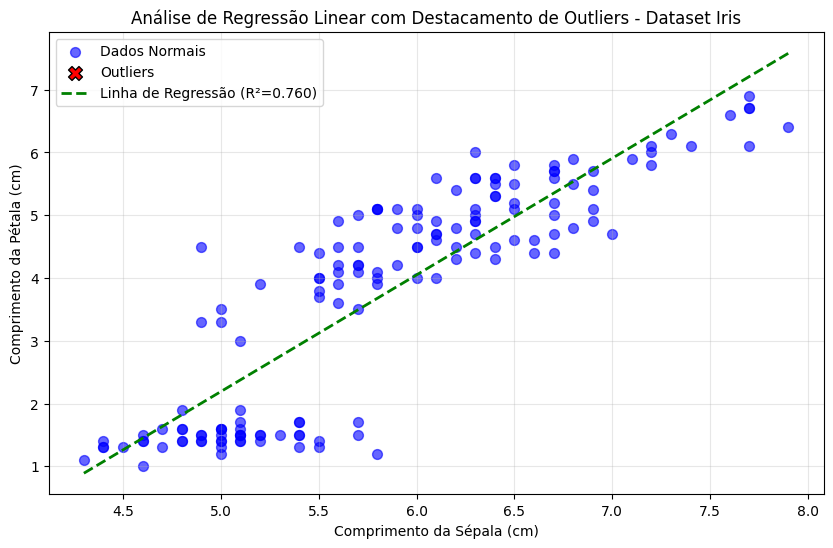

In [ ]:
# Preparar os dados para regressão linear
X_reg = dados_filtrados[['sepal length (cm)']].values
y_reg = dados_filtrados['petal length (cm)'].values

# Treinar o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X_reg, y_reg)

# Gerar pontos para a linha de regressão
x_linha = np.linspace(X['sepal length (cm)'].min(), X['sepal length (cm)'].max(), 100)
y_linha = modelo.predict(x_linha.reshape(-1, 1))

# Criar o gráfico
plt.figure(figsize=(10, 6))

# Plotar os pontos normais (azul)
plt.scatter(dados_filtrados['sepal length (cm)'], dados_filtrados['petal length (cm)'],
            c='blue', alpha=0.6, s=50, label='Dados Normais')

# Plotar os outliers (vermelho com borda preta)
plt.scatter(outliers_data['sepal length (cm)'], outliers_data['petal length (cm)'],
            c='red', edgecolors='black', s=100, marker='X', label='Outliers')

# Plotar a linha de regressão (linha de tendência)
plt.plot(x_linha, y_linha, color='green', linewidth=2, linestyle='--', label=f'Linha de Regressão (R²={modelo.score(X_reg, y_reg):.3f})')

# Títulos e labels
plt.title('Análise de Regressão Linear com Destacamento de Outliers - Dataset Iris')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

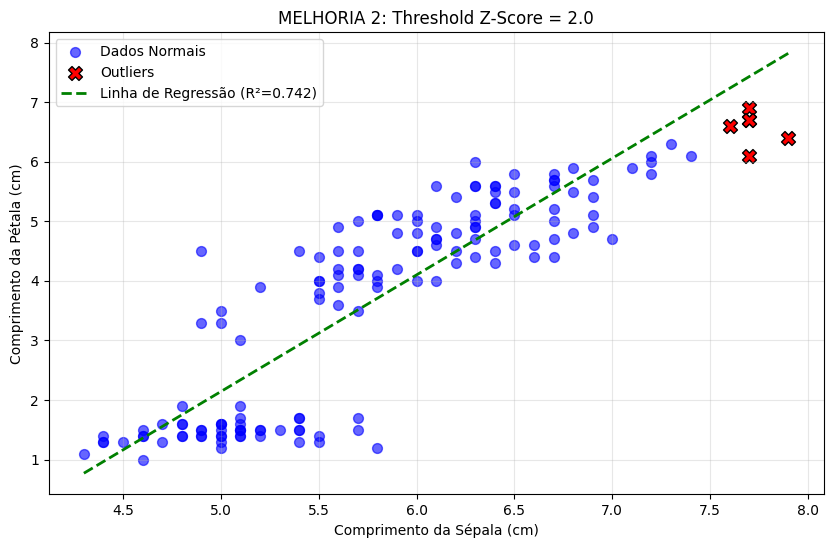

Threshold 2.0: 6 outliers detectados


In [ ]:
# ========================
# MELHORIA 2: Threshold 2.0
# ========================
# Reduzindo para 2.0 (menos outliers)

z_scores = np.abs(stats.zscore(X))
threshold = 2.0

outliers = (z_scores > threshold).any(axis=1)
dados_filtrados = X[~outliers]
outliers_data = X[outliers]

# Regressão linear
X_reg = dados_filtrados[['sepal length (cm)']].values
y_reg = dados_filtrados['petal length (cm)'].values
modelo = LinearRegression()
modelo.fit(X_reg, y_reg)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(dados_filtrados['sepal length (cm)'], dados_filtrados['petal length (cm)'],
            c='blue', alpha=0.6, s=50, label='Dados Normais')
plt.scatter(outliers_data['sepal length (cm)'], outliers_data['petal length (cm)'],
            c='red', edgecolors='black', s=100, marker='X', label='Outliers')

x_linha = np.linspace(X['sepal length (cm)'].min(), X['sepal length (cm)'].max(), 100)
y_linha = modelo.predict(x_linha.reshape(-1, 1))
plt.plot(x_linha, y_linha, color='green', linewidth=2, linestyle='--',
        label=f'Linha de Regressão (R²={modelo.score(X_reg, y_reg):.3f})')

plt.title('MELHORIA 2: Threshold Z-Score = 2.0')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Threshold 2.0: {outliers.sum()} outliers detectados")

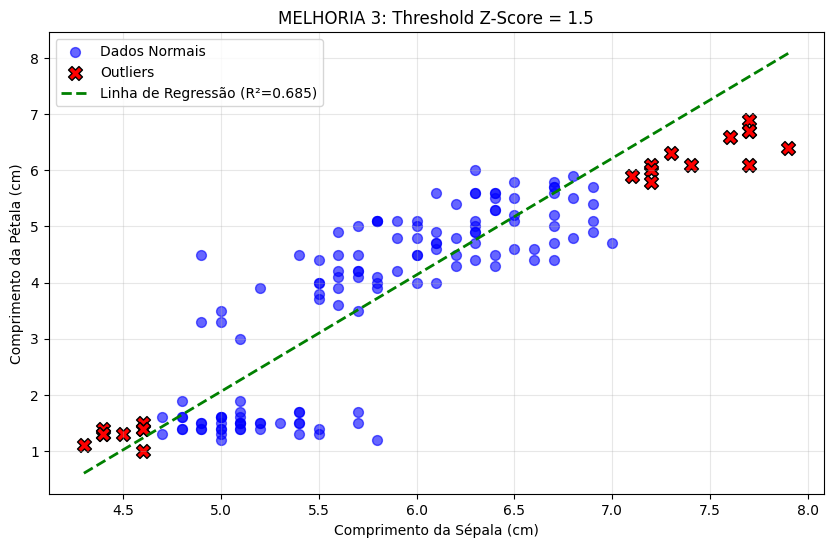

Threshold 1.5: 21 outliers detectados


In [ ]:
# ========================
# MELHORIA 3: Threshold 1.5
# ========================
# Reduzindo para 1.5 (menos outliers ainda)

z_scores = np.abs(stats.zscore(X))
threshold = 1.5

outliers = (z_scores > threshold).any(axis=1)
dados_filtrados = X[~outliers]
outliers_data = X[outliers]

# Regressão linear
X_reg = dados_filtrados[['sepal length (cm)']].values
y_reg = dados_filtrados['petal length (cm)'].values
modelo = LinearRegression()
modelo.fit(X_reg, y_reg)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(dados_filtrados['sepal length (cm)'], dados_filtrados['petal length (cm)'],
            c='blue', alpha=0.6, s=50, label='Dados Normais')
plt.scatter(outliers_data['sepal length (cm)'], outliers_data['petal length (cm)'],
            c='red', edgecolors='black', s=100, marker='X', label='Outliers')

x_linha = np.linspace(X['sepal length (cm)'].min(), X['sepal length (cm)'].max(), 100)
y_linha = modelo.predict(x_linha.reshape(-1, 1))
plt.plot(x_linha, y_linha, color='green', linewidth=2, linestyle='--',
        label=f'Linha de Regressão (R²={modelo.score(X_reg, y_reg):.3f})')

plt.title('MELHORIA 3: Threshold Z-Score = 1.5')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Threshold 1.5: {outliers.sum()} outliers detectados")

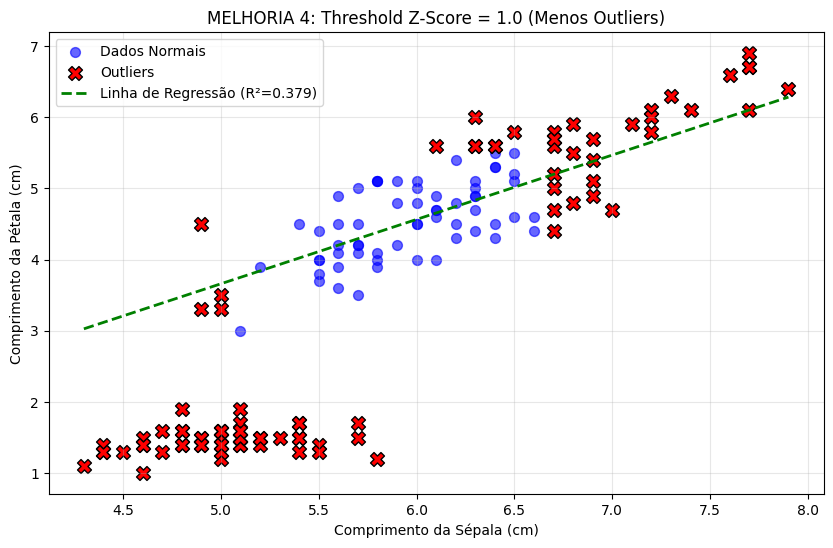

Threshold 1.0: 89 outliers detectados


In [ ]:
# ========================
# MELHORIA 4: Threshold 1.0
# ========================
# Threshold mínimo (menos outliers possível)

z_scores = np.abs(stats.zscore(X))
threshold = 1.0

outliers = (z_scores > threshold).any(axis=1)
dados_filtrados = X[~outliers]
outliers_data = X[outliers]

# Regressão linear
X_reg = dados_filtrados[['sepal length (cm)']].values
y_reg = dados_filtrados['petal length (cm)'].values
modelo = LinearRegression()
modelo.fit(X_reg, y_reg)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(dados_filtrados['sepal length (cm)'], dados_filtrados['petal length (cm)'],
            c='blue', alpha=0.6, s=50, label='Dados Normais')
plt.scatter(outliers_data['sepal length (cm)'], outliers_data['petal length (cm)'],
            c='red', edgecolors='black', s=100, marker='X', label='Outliers')

x_linha = np.linspace(X['sepal length (cm)'].min(), X['sepal length (cm)'].max(), 100)
y_linha = modelo.predict(x_linha.reshape(-1, 1))
plt.plot(x_linha, y_linha, color='green', linewidth=2, linestyle='--',
        label=f'Linha de Regressão (R²={modelo.score(X_reg, y_reg):.3f})')

plt.title('MELHORIA 4: Threshold Z-Score = 1.0 (Menos Outliers)')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Threshold 1.0: {outliers.sum()} outliers detectados")